# Experiment No. 8
## Compare Different Classification Algorithms Using Precision, Recall, and Accuracy
## Aim

To implement and compare multiple classification algorithms on the Iris dataset and evaluate their performance using Precision, Recall, and Accuracy metrics.
## Objectives

- Study different machine learning classification algorithms.
- Apply multiple classifiers to the Iris dataset.
- Evaluate classifiers using Accuracy, Precision, and Recall.
- Compare the predictive performance of different algorithms.
- Analyze classifier performance using confusion matrices.
- Validate model performance using cross-validation.
## Dataset

**Dataset:** Iris Dataset

**Problem Statement:** Classify Iris flowers into Setosa, Versicolor, and Virginica based on sepal and petal measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Number of Classes:", len(target_names))
print("Classes:", list(target_names))

Dataset Shape: (150, 4)
Number of Features: 4
Number of Classes: 3
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [3]:
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df["Species"] = [target_names[i] for i in y]

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Dataset Information:\n")
print(iris_df.info())

print("\nClass Distribution:\n")
print(iris_df["Species"].value_counts())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Class Distribution:

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Exploratory Data Analysis

In [5]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


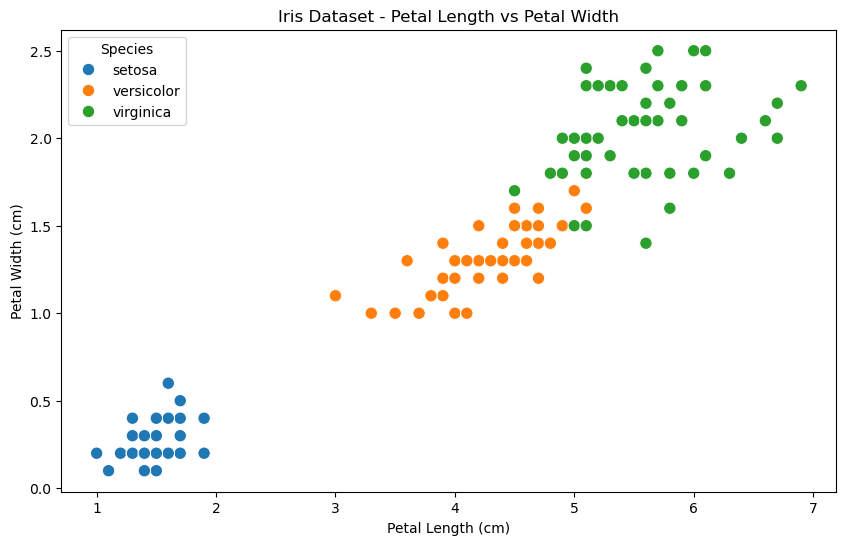

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=iris_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Species",
    s=80
)

plt.title("Iris Dataset - Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.show()

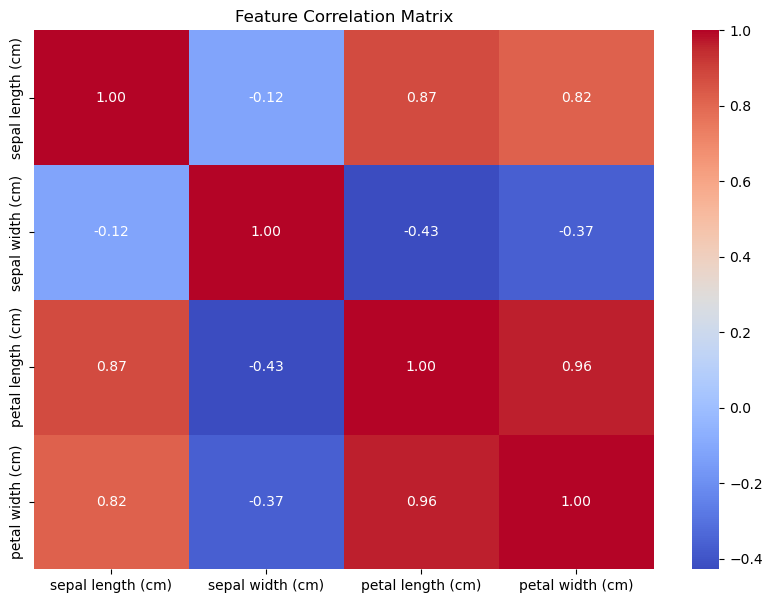

In [7]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    iris_df.drop(columns="Species").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

## Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 120
Testing Samples: 30


## Feature Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Classification Models

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

print("Models Used:")
for model_name in models:
    print("-", model_name)

Models Used:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN
- Naive Bayes


## Model Training and Evaluation

In [11]:
results = []
predictions = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    results.append([
        name,
        precision,
        recall,
        accuracy
    ])

results_df = pd.DataFrame(
    results,
    columns=["Algorithm", "Precision", "Recall", "Accuracy"]
)

results_df = results_df.round(4)

results_df

,Algorithm,Precision,Recall,Accuracy
0,Logistic Regression,0.9333,0.9333,0.9333
1,Decision Tree,0.9333,0.9333,0.9333
2,Random Forest,0.9024,0.9000,0.9000
3,SVM,0.9697,0.9667,0.9667
4,KNN,0.9444,0.9333,0.9333
5,Naive Bayes,0.9697,0.9667,0.9667


## Performance Comparison

In [12]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Algorithm,Precision,Recall,Accuracy
0,Naive Bayes,0.9697,0.9667,0.9667
1,SVM,0.9697,0.9667,0.9667
2,Decision Tree,0.9333,0.9333,0.9333
3,Logistic Regression,0.9333,0.9333,0.9333
4,KNN,0.9444,0.9333,0.9333
5,Random Forest,0.9024,0.9000,0.9000


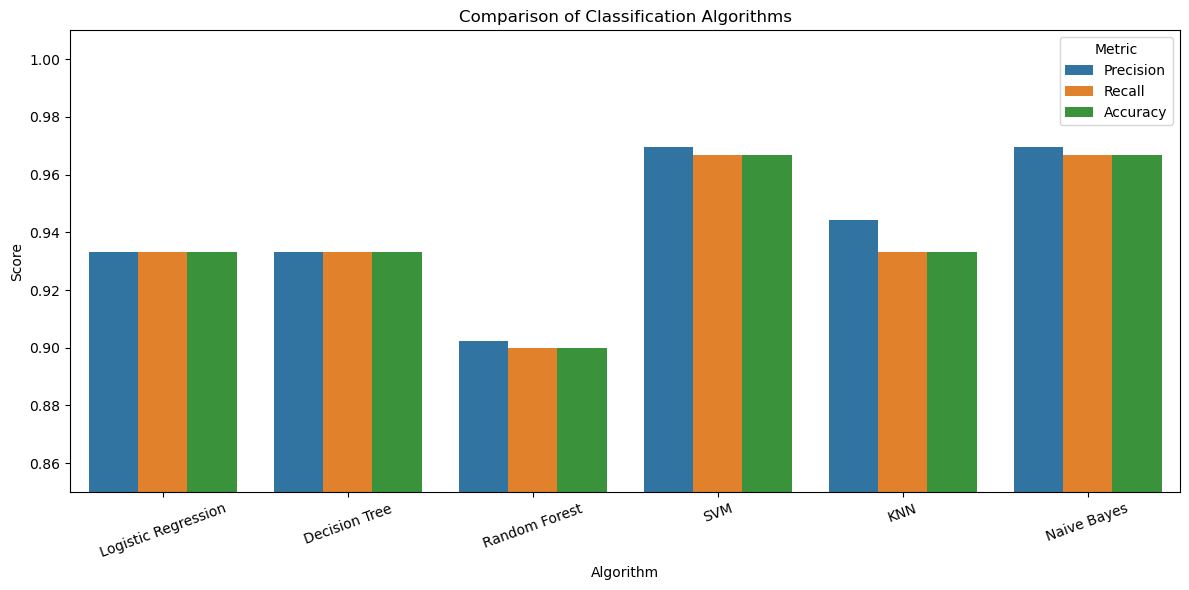

In [13]:
results_melted = results_df.melt(
    id_vars="Algorithm",
    value_vars=["Precision", "Recall", "Accuracy"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Algorithm",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Classification Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Confusion Matrices

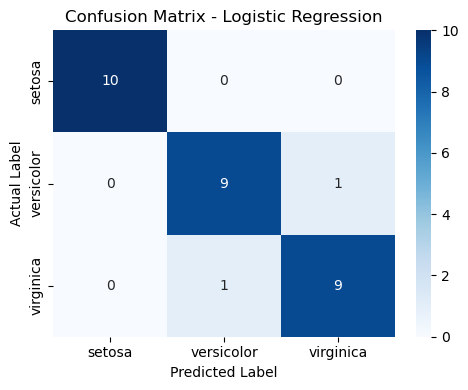

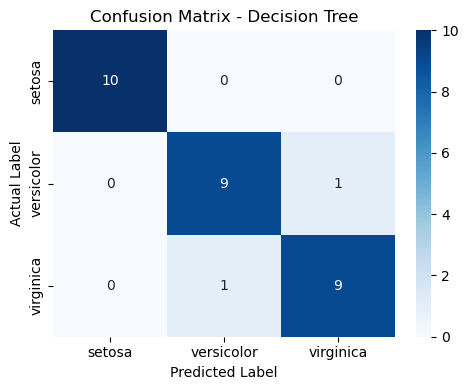

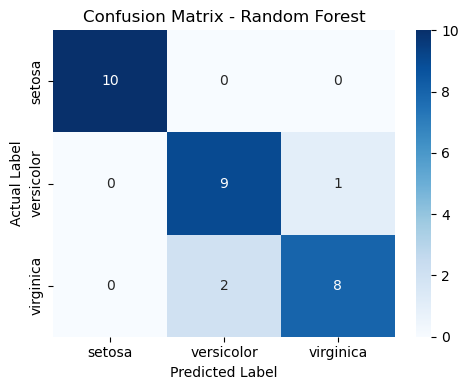

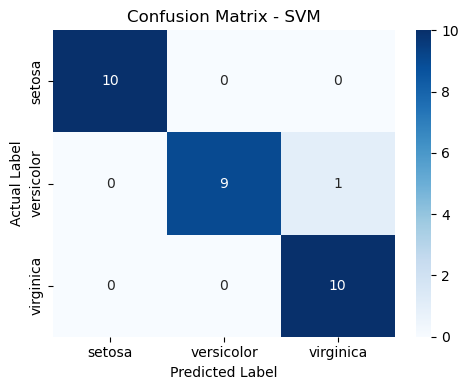

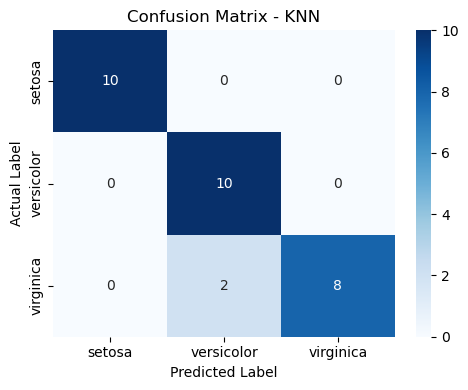

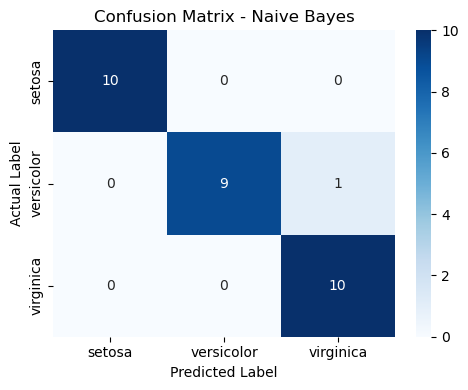

In [14]:
for name, y_pred in predictions.items():
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

## Classification Reports`

In [15]:
for name, y_pred in predictions.items():
    
    print("=" * 70)
    print(name)
    print("=" * 70)
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_names,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89    

## 5-Fold Cross-Validation

Cross-validation is used to obtain a more reliable estimate of model performance across different subsets of the dataset.

In [16]:
cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Algorithm",
        "Mean CV Accuracy",
        "Standard Deviation"
    ]
)

cv_df = cv_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

cv_df.round(4)

,Algorithm,Mean CV Accuracy,Standard Deviation
0,KNN,0.9667,0.0312
1,SVM,0.9667,0.0312
2,Naive Bayes,0.9583,0.0264
3,Logistic Regression,0.9583,0.0264
4,Random Forest,0.9500,0.0167
5,Decision Tree,0.9417,0.0204


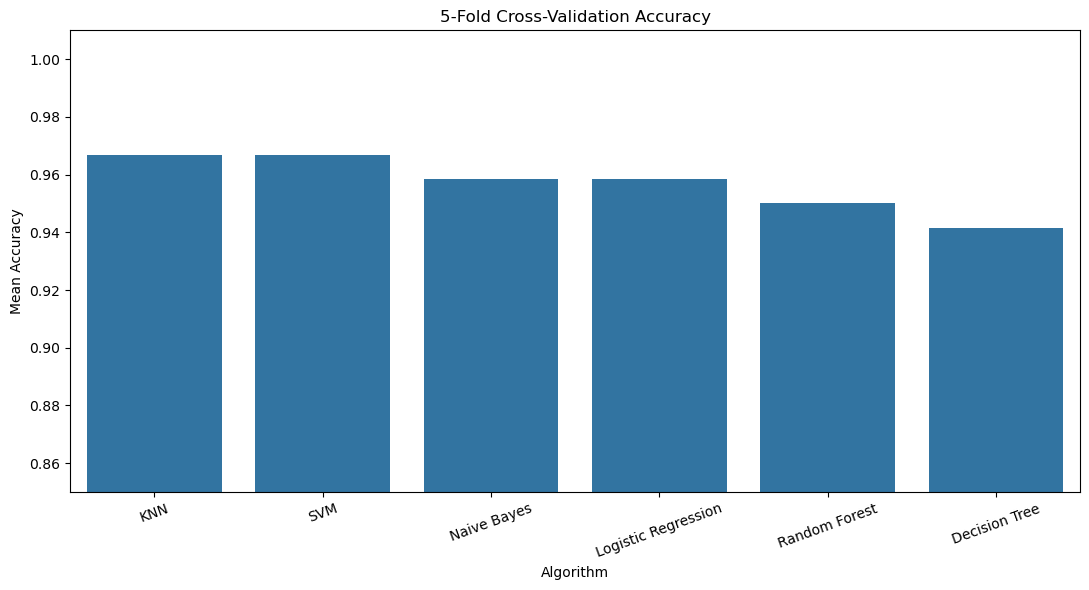

In [17]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=cv_df,
    x="Algorithm",
    y="Mean CV Accuracy"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Mean Accuracy")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Best Performing Algorithm

In [18]:
best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Algorithm"
]

best_precision_model = results_df.loc[
    results_df["Precision"].idxmax(),
    "Algorithm"
]

best_recall_model = results_df.loc[
    results_df["Recall"].idxmax(),
    "Algorithm"
]

best_cv_model = cv_df.loc[
    cv_df["Mean CV Accuracy"].idxmax(),
    "Algorithm"
]

print("Best Accuracy:", best_accuracy_model)
print("Best Precision:", best_precision_model)
print("Best Recall:", best_recall_model)
print("Best Cross-Validation Accuracy:", best_cv_model)

Best Accuracy: SVM
Best Precision: SVM
Best Recall: SVM
Best Cross-Validation Accuracy: KNN


In [19]:
final_comparison = results_df.copy()

final_comparison["Overall Score"] = (
    final_comparison["Precision"]
    + final_comparison["Recall"]
    + final_comparison["Accuracy"]
) / 3

final_comparison = final_comparison.sort_values(
    by="Overall Score",
    ascending=False
).reset_index(drop=True)

final_comparison.round(4)

,Algorithm,Precision,Recall,Accuracy,Overall Score
0,Naive Bayes,0.9697,0.9667,0.9667,0.9677
1,SVM,0.9697,0.9667,0.9667,0.9677
2,KNN,0.9444,0.9333,0.9333,0.9370
3,Logistic Regression,0.9333,0.9333,0.9333,0.9333
4,Decision Tree,0.9333,0.9333,0.9333,0.9333
5,Random Forest,0.9024,0.9000,0.9000,0.9008


## Prediction on New Sample

In [20]:
new_flower = np.array([[5.8, 2.7, 4.1, 1.0]])

new_flower_scaled = scaler.transform(new_flower)

print("New Flower Measurements:")
print(new_flower)

print("\nPredictions:\n")

for name, model in models.items():
    
    prediction = model.predict(new_flower_scaled)[0]
    
    print(
        f"{name}: {target_names[prediction]}"
    )

New Flower Measurements:
[[5.8 2.7 4.1 1. ]]

Predictions:

Logistic Regression: versicolor
Decision Tree: versicolor
Random Forest: versicolor
SVM: versicolor
KNN: versicolor
Naive Bayes: versicolor


## Conclusion

Multiple classification algorithms were implemented on the Iris dataset and evaluated using Accuracy, Precision, and Recall. Logistic Regression, Decision Tree, Random Forest, SVM, KNN, and Naive Bayes were compared.

Confusion matrices and classification reports were used for detailed evaluation, while 5-fold cross-validation was performed to obtain a more reliable estimate of model performance.

The best-performing algorithm can be selected based on the required evaluation metric and the consistency of its cross-validation performance.